# Active Forces on Rigid Bodies

## Overview

### Questions

* How do we correctly model active forces to an arbitrary rigid body for use in HOOMD-blue?

### Objectives

* Define a **rigid body** as a **central particle** and a set of constituent particles in a lattice. 
* Understand how to model **driven active matter systems** by applying an **active force** to the rigid body.

## Boilerplate Code

In [1]:
import io
import itertools

import gsd.hoomd
import hoomd
import numpy
import PIL

In [2]:
import os

fn = os.path.join(os.getcwd(), "lattice.gsd")
![ -e "$fn" ] && rm "$fn"
fn = os.path.join(os.getcwd(), "active_torque.gsd")
![ -e "$fn" ] && rm "$fn"

The `render_rigid_body` function in the next (hidden) cell will render the rigid body using 
**fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [3]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import os
import warnings

import fresnel
import IPython
import packaging.version

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if (
        "version" not in dir(fresnel)
        or packaging.version.parse(fresnel.version.version) < FRESNEL_MIN_VERSION
        or packaging.version.parse(fresnel.version.version) >= FRESNEL_MAX_VERSION
    ):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])
    constituent_color = fresnel.color.linear([93 / 255, 210 / 255, 252 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(
        scene, N=len(snapshot.particles.position), radius=0.5
    )
    geometry.material = fresnel.material.Material(
        color=[0, 0, 0], roughness=0.5, primitive_color_mix=1.0
    )
    geometry.position[:] = snapshot.particles.position[:]
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.3
    geometry.color[snapshot.particles.typeid[:] == 1] = constituent_color
    geometry.outline_width = 0.04
    fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=0.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1), color=(0.8, 0.8, 0.8), theta=numpy.pi),
        fresnel.light.Light(
            direction=(1, 1, 1), color=(1.1, 1.1, 1.1), theta=numpy.pi / 3
        ),
    ]
    scene.camera = fresnel.camera.Orthographic(
        position=(L * 2, L, L * 2), look_at=(0, 0, 0), up=(0, 1, 0), height=L * 1.4 + 1
    )
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    samples = 2000
    if "CI" in os.environ:
        samples = 100
    return IPython.display.Image(tracer.sample(scene, samples=samples)._repr_png_())


def render_movie(frames, particles=None, is_solid=None):
    if is_solid is None:
        is_solid = [None] * len(frames)
    a = render(frames[0], particles, is_solid[0])

    im0 = PIL.Image.fromarray(a[:, :, 0:3], mode="RGB").convert(
        "P", palette=PIL.Image.Palette.ADAPTIVE
    )
    ims = []
    for i, f in enumerate(frames[1:]):
        a = render(f, particles, is_solid[i])
        im = PIL.Image.fromarray(a[:, :, 0:3], mode="RGB")
        im_p = im.quantize(palette=im0)
        ims.append(im_p)

    blank = numpy.ones(shape=(im.height, im.width, 3), dtype=numpy.uint8) * 255
    im = PIL.Image.fromarray(blank, mode="RGB")
    im_p = im.quantize(palette=im0)
    ims.append(im_p)

    f = io.BytesIO()
    im0.save(f, "gif", save_all=True, append_images=ims, duration=1000, loop=0)

    size = len(f.getbuffer()) / 1024
    if size > 3000:
        warnings.warn(f"Large GIF: {size} KiB")
    return IPython.display.display(IPython.display.Image(data=f.getvalue()))


device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render_rigid_body(pos_body, radius_constituent=1):
    if (
        "version" not in dir(fresnel)
        or packaging.version.parse(fresnel.version.version) < FRESNEL_MIN_VERSION
        or packaging.version.parse(fresnel.version.version) >= FRESNEL_MAX_VERSION
    ):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )

    L = 3 * numpy.max(numpy.linalg.norm(pos_body, axis=1))
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(
        scene, N=len(pos_body), radius=radius_constituent
    )
    geometry.material = fresnel.material.Material(
        color=fresnel.color.linear([93 / 255, 210 / 255, 252 / 255]), roughness=0.5
    )
    geometry.position[:] = pos_body
    geometry.outline_width = 0.04
    fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=0.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1), color=(0.8, 0.8, 0.8), theta=numpy.pi),
        fresnel.light.Light(
            direction=(1, 1, 1), color=(1.1, 1.1, 1.1), theta=numpy.pi / 3
        ),
    ]
    scene.camera = fresnel.camera.Orthographic(
        position=(L * 2, L, L * 2), look_at=(0, 0, 0), up=(0, 1, 0), height=L * 1.4 + 1
    )
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    samples = 2000
    if "CI" in os.environ:
        samples = 100
    return IPython.display.Image(tracer.sample(scene, samples=samples)._repr_png_())

## Applying active forces to rigid bodies

This tutorial demonstrates how to simulate active Brownian particles made up of **rigid bodies** using HOOMD-blue. Accurately applying active forces to rigid bodies is essential for realistic physical simulations. Active forces and torques can arise from self-propulsion or self-rotational mechanisms, external fields, or internal actuation, and they strongly influence collective dynamics and emergent behavior. 

In the previous tutorials, we applied active forces on the central particle of rigid bodies. Alternatively, adding active torque to a rigid body would simulate self-rotation. 

One could alternatively apply an active force on a constituent particle which is not located on the center of mass. Any active torque applied not in line with the radius will induce an active torque. It is recommended to avoid doing so. To acheive this effect, one should instead consider applying an active torque on your system as below unless there is a good reason for doing so.

For a full tutorial on modelling rigid bodies please see the [Modeling Rigid Bodies](https://github.com/glotzerlab/hoomd-examples/tree/activity-tutorial/06-Modelling-Rigid-Bodies) tutorial.  


Here we give an example of a system where only **active torques** are applied. Some examples where such a system may be relevant include the development of starfish embryos or using bacteria bath to assemble active colloids. 

To model this system, we will first set up our simulation identically as done in the previous tutorials.

## Set up the Simulation 
We will first initialize a system of rigid bodies with a given particle density in an array. We create an initial configuration of dimers with a frame containing both particle types.

In [4]:
m = 4
N_particles = m**3
spacing = 5
K = numpy.ceil(N_particles ** (1 / 3))
L = K * spacing
x = numpy.linspace(-L / 2, L / 2, int(K), endpoint=False)
position = list(itertools.product(x, repeat=3))
position = numpy.array(position) + [spacing / 2, spacing / 2, spacing / 2]

frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position[0:N_particles, :]
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [L, L, L, 0, 0, 0]
frame.particles.types = ["dimer", "A"]
frame.particles.mass = [2] * N_particles
frame.particles.orientation = [(1, 0, 0, 0)] * N_particles

Compute the moment of inertia of the dimer. Computing this is essential to accurate rotational updating of the rigid body. 

In [5]:
particle_mass = 1
particle_radius = 1
dimer_positions = [[1.2, 0, 0],[-1.2, 0, 0]]
I = numpy.zeros(shape=(3, 3))
for r in dimer_positions:
    I += particle_mass * (numpy.dot(r, r) * numpy.identity(3) - numpy.outer(r, r))
frame.particles.moment_inertia = [I[0, 0], I[1, 1], I[2, 2]] * N_particles

Write the rigid centers to a GSD file for later use:

In [6]:
with gsd.hoomd.open(name="lattice.gsd", mode="w") as f:
    f.append(frame)

Configure the simulation to run on the CPU using this snapshot, as done in previous tutorials. Here, we also define the constituent particle properties in body coordinates for the rigid body type. After creating the rigid bodies, visualize the resulting configuration:

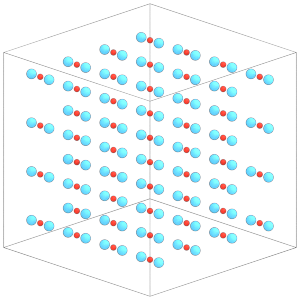

In [7]:
simulation = hoomd.Simulation(device=hoomd.device.CPU(), seed=1)
state = simulation.create_state_from_gsd(filename="lattice.gsd")

rigid = hoomd.md.constrain.Rigid()
rigid.body["dimer"] = {
    "constituent_types": ["A", "A"],
    "positions": dimer_positions,
    "orientations": [(1.0, 0.0, 0.0, 0.0), (1.0, 0.0, 0.0, 0.0)],
}
rigid.create_bodies(simulation.state)
render(simulation.state.get_snapshot())

In [8]:
filter_all = hoomd.filter.All()
filter_free = hoomd.filter.Rigid(("center","free"))
filter_dimer = hoomd.filter.Type(['dimer'])

Apply the `OverdampedViscous` integrator and set kT=0 to make active translation more obvious. We want to allow our rigid bodies to rotate, so it’s important to integrate the rotational degrees of freedom. Thus, we set `integrate_rotational_dof` = `True` unlike in the previous tutorial notebook.

Importantly, note that the initigrator, we have added the argument `rigid=rigid`. This is the argument that tells the HOOMD integrator to treat the particles defined by the Rigid object as a single rigid body, so it integrates only the center particle's translation and rotation and then updates the constituent particles' positions/orientations to maintain the fixed internal geometry.

In [9]:
kT = 0
gamma = 1

filter_free = hoomd.filter.Rigid(("center", "free"))

overdamped = hoomd.md.methods.OverdampedViscous(filter=filter_free)
overdamped.gamma.default = gamma
overdamped.gamma_r.default = [gamma / 3, gamma / 3, gamma / 3]


integrator = hoomd.md.Integrator(dt=0.001, 
                                 rigid=rigid, 
                                 integrate_rotational_dof=True)
simulation.operations.integrator = integrator
integrator.methods.append(overdamped)

## Apply our active force

When applying an active force to a rigid body, which particle(s) the active force is applied to matters. This can be applied to the **central** particle of the rigid body (here, this is `dimer`) or the body's constituent partcles. Regardless of which particles you choose, the central particle holds all the information provided regarding the force. Only one active force should be applied to the central particle of the rigid body. In this case this particle is `dimer`. This central particle can be the center of mass of the rigid body but this is not neccessary although it is not particularly recommended. 

Notice that we do not create a `rotational_diffusion_updater` here unlike in previous tutorials of active forces. We do so only for point particles. This is because, in `HOOMD-blue`, a rigid body's orientation is one of the system's dynamical degrees of freedom, and the integrator updates it by solving the rotational equations of motion. If we were to apply a `rotational_diffusion_updater` to a rigid body, we would be manually changing its orientation in addition to the integrator's rotational dynamics. This would effectively add an extra source of rotational noise that is not part of the rigid-body equations of motion and would generally be unphysical.

Below we apply an active force in the x and y body coordinates solely because it provides easier visualization for the sake of this tutorial.

In [10]:
activity = 0.3 # x and y force component

active = hoomd.md.force.Active(filter=filter_dimer)
active.active_force["dimer"] = (activity, activity, 0)
active.active_torque["dimer"] = (0, 0, 0)

integrator.forces.append(active)


Write simulation data to a GSD trajectory file every 100 steps. 

In [11]:
logger = hoomd.logging.Logger(["particle", "constraint"])
gsd_oper = hoomd.write.GSD(
    trigger=hoomd.trigger.Periodic(100),
    filename="active.gsd",
    logger=logger,
    mode="wb",
    dynamic=["momentum", "property"],
    filter=hoomd.filter.All(),
)

simulation.operations += gsd_oper

Thermalize particle momenta and see initial configuration to compare to later trajectory frame.

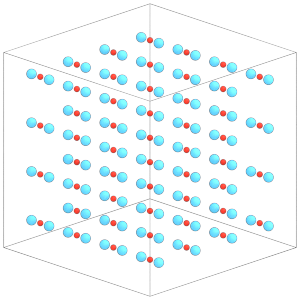

In [12]:
simulation.state.thermalize_particle_momenta(filter=filter_all, kT=kT)
simulation.run(0)
render(simulation.state.get_snapshot())

Run the simulation. Since kT=0 in this simulation, any observed particle motion must result from the active propulsion force applied to the rigid bodies. Here, the entire rigid body is propelled by the force applied to its center of mass because the `active_force` is applied to the central body particle `dimer`. The body's orientation and position evolves over time, and the constituent particles follow accordingly. i.e. Although the force is explicitly applied only to the central dimer particle, the entire rigid body translates collectively, as expected. This confirms that the active force is correctly coupled to the rigid body and propagated to its constituent particles. 

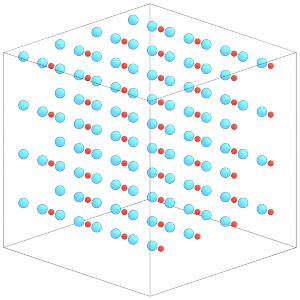

In [13]:
simulation.run(5000)
gsd_oper.flush()
render(simulation.state.get_snapshot())

## Apply an Active Torque

Finally, we will demonstrate the application of an active torque on this system. This again requires that we set the argument in the simulation integrator `integrate_rotational_dof=True`. For ease of visualization of the active torque, we will first remove the linear active force so that the center of mass of each dimer will remain stationary.

In [14]:
integrator.forces.remove(active)

We now apply an active torque analogously to the linear active force. 

In [15]:
tau = 0.3

active = hoomd.md.force.Active(filter=filter_dimer)
active.active_force["dimer"] = (0, 0, 0)
active.active_torque["dimer"] = (0, 0, tau)

integrator.forces.append(active)

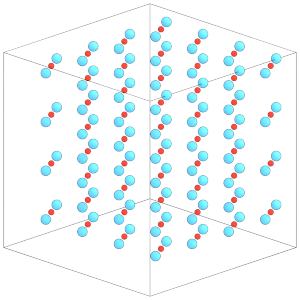

In [16]:
simulation.run(1000)
gsd_oper.flush()
render(simulation.state.get_snapshot())

Again, since kT=0, any observed change in orientation must be due to the applied active torque on our dimers. We can see by visual inspection that each of our dimers are correctly rotated by an active torque as individual rigid bodies. 